# Profiling

In [1]:
from lucifex.fdm import AB, CN
from lucifex.sim import run
from lucifex.solver import OptionsPETSc
from lucifex.viz import (
    plot_line, save_figure, 
    get_ipynb_file_name, set_ipynb_variable,
)
from crocodil.dns.system_a import dns_system_a, SYSTEM_A_REFERENCE 

STORE = 1
WRITE = None
DIR_BASE = f'./{get_ipynb_file_name()}'
NX = 60
NY = 60

simulation = dns_system_a(
    store_delta=STORE, 
    write_delta=WRITE, 
    dir_base=DIR_BASE, 
)(
    Nx=NX,
    Ny=NY,
    scaling='advective',
    **SYSTEM_A_REFERENCE,
    D_adv=AB(1)@CN, 
    D_diff=AB(1)@CN,
    dt_max=0.1,
    courant_adv=0.75,
    courant_diff=0.75,
    courant_reac=0.1,
    flow_petsc=(OptionsPETSc('cg', 'hypre'), None),
    diagnostic=True,
)

n_stop = set_ipynb_variable('N_STOP', 100)
t_stop = 100.0
dt_init = 1e-6
n_init = 6
run(simulation, n_stop=n_stop, t_stop=t_stop, dt_init=dt_init, n_init=n_init, timing=True)

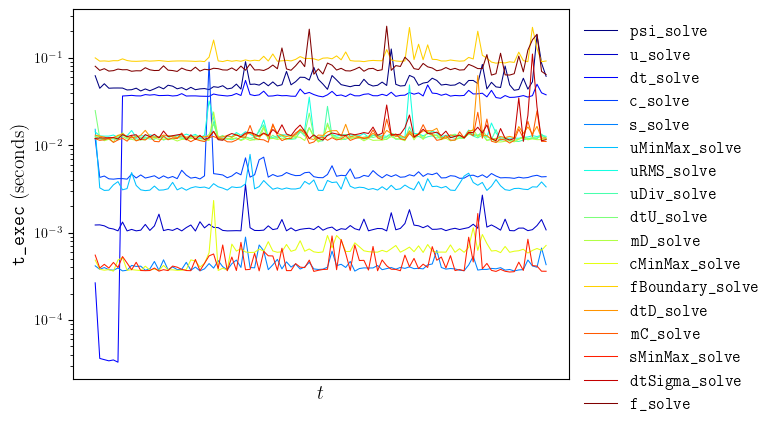

In [2]:
timings = simulation.timings

key_filter = lambda k: 'solve' in k
lines = [(range(len(v)), v) for k, v in timings.items() if key_filter(k)]
legend_labels = [f'$\\texttt{{{k}}}$' for k in timings if key_filter(k)]

fig, ax = plot_line(
    lines,
    cyc='jet',
    legend_labels=legend_labels,
    x_label='$t$',
    y_label='$\\texttt{t\\_exec}$ (seconds)',
)
ax.set_xticks([])
ax.set_yscale('log')

save_figure('tExec(t)', simulation.dir_path, prefix_ipynb=False)(fig)